In [1]:
config_path = './results/new_design/config.yaml'
import numpy as np; import matplotlib.pyplot as plt # type: ignore
import src.math_tool as mt
import src.img_tool as it
import src.apertures as apertures
import src.load_config as lc
import gc
%load_ext autoreload
%autoreload 2
%matplotlib widget
c, π = lc.load(config_path), np.pi
x, y = np.meshgrid(c.sim.xs + c.Δx/2, c.sim.ys + c.Δy/2, indexing='ij') # use center coordinate of pixel
Nθs = 64
θ0s = np.linspace(0, 2*π, Nθs, endpoint=False, dtype=np.float32) #test phase, for optimization

cannot load aperture file


simulation of light at designed focal point passing back to aperture

find phase at aperture of light propagate from a designed focal pattern

In [2]:
target_size = 200
arr = (it.img_2_array('img/HKUST_QR.bmp')).T
print(arr.shape)
arr = arr[10::43, 10::43]
print(arr.shape)
idx = np.argwhere(arr==False)
Lx, Ly = arr.shape[0], arr.shape[1]
Δx, Δy = 1/Lx, 1/Ly
x_f_point = (idx[:, 0] - (Lx-1)/2)*target_size/Lx
y_f_point = ((Ly-1)/2 - idx[:, 1])*target_size/Ly# N_point
N = len(idx)
θ_f_point = np.zeros(N)
magnitude_f_point = np.ones(N) 
z_f_point = np.ones(N) * 5e3 # focal dist at 5mm

(912, 912)
(21, 21)


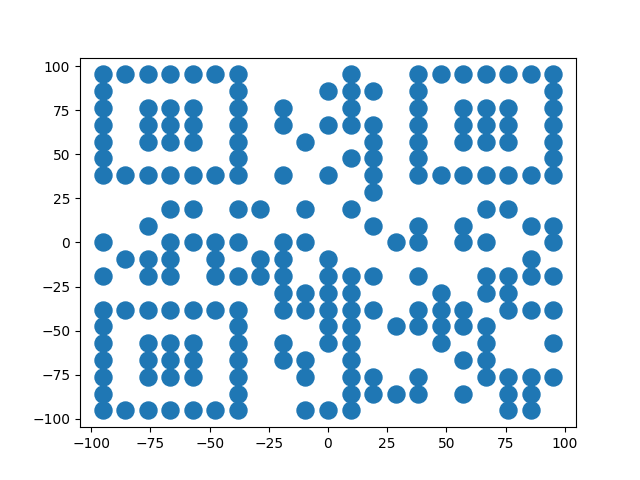

In [3]:
plt.cla()
plt.scatter(x_f_point, y_f_point, s=150)
plt.show()

In [4]:
# r = mt.dist(x[:, :, None], y[:, :, None], z=0, x_c = x_f_point, y_c=y_f_point, z_c = z_f_point) # Nx, Ny, N_point
# # Rayleigh Sommerfeld summation
# E = (-1j/c.λ * np.exp(c.k*1j*r)*z_f_point/r**2)@(np.exp(1j*θ_f_point)*magnitude_f_point) # Nx, Ny
split = 4
E = 0
for i in range(split): # for computer with tiny RAM
    r = mt.dist(x[:, :, None], y[:, :, None], z=0, x_c = x_f_point[i::split], y_c=y_f_point[i::split], z_c = z_f_point[i::split]) # Nx, Ny, N_point / split
    # Rayleigh Sommerfeld summation
    E += (-1j/c.λ * np.exp(c.k*1j*r)*z_f_point[i::split]/r**2)@(np.exp(1j*θ_f_point[i::split])*magnitude_f_point[i::split]) # Nx, Ny
    del r
    gc.collect()

deleted r
deleted r
deleted r
deleted r


In [7]:
θ_aperture = np.angle(E)
edge = apertures.block_edge_mask(1024, 1024, 500) # Nx, Ny # circle mask of Nx x Ny pixel with pixel radius
cos_θ_aperture_θ0s = np.cos(θ_aperture[..., None]-θ0s) # Nx, Ny, Nθs
# apply constraint of 500μm diameter
aperture_design = (cos_θ_aperture_θ0s > 0) * edge[:, :, None]
# find best possible match over range of reference phase
#                  phase_similarity (Nx, Ny, Nθs)
cosine_similarity = (cos_θ_aperture_θ0s * aperture_design * np.abs(E)[:, :, None]).sum(axis=(0, 1)) # Nθs (range of reference phase)
idx_max = cosine_similarity.argmax()
idx_min = cosine_similarity.argmin()
print(f'min similarity phase / max similarity phase\n{cosine_similarity[idx_min] / cosine_similarity[idx_max]}')

min similarity phase / max similarity phase
0.8084204029343923


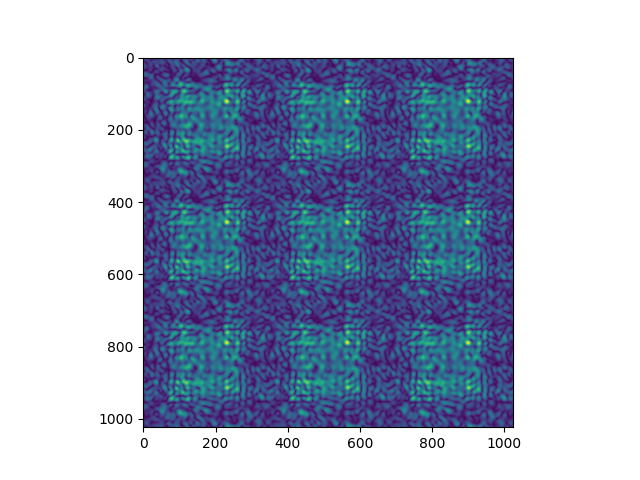

In [8]:
layout = [[0, 1]]
fig, ax = plt.subplot_mosaic(layout, figsize=(10,6))
ax[0].imshow(np.abs(E).T) # examine if most high activation region is resolved properly, otherwise may lead to bad reconstruction
ax[1].imshow(aperture_design[..., idx_max].T)
plt.show()

In [13]:
name = '_sample_QR_f5_512'
name2 = '_sample_QR_f5_512_zoomx2_padx2'
aperture = aperture_design[..., idx_max]
it.array_2_img(aperture, f'aperture/tmp/{name}.bmp')
aperture = np.repeat(aperture, 2, axis=0)
aperture = np.repeat(aperture, 2, axis=1)
aperture = it.img_pad(aperture, N_pad_xy=(512, 512, 512, 512), pad_val=False)
it.array_2_img(aperture, f'aperture/tmp/{name2}.bmp')